***
Original Data : ***
   Data.Precipitation  Date.Full  Date.Month  Date.Week of  Date.Year  \
0                0.00 2016-01-03           1             3       2016   
1                0.00 2016-01-03           1             3       2016   
2                0.16 2016-01-03           1             3       2016   
3                0.00 2016-01-03           1             3       2016   
4                0.01 2016-01-03           1             3       2016   

  Station.City Station.Code Station.Location Station.State  \
0   Birmingham          BHM   Birmingham, AL       Alabama   
1   Huntsville          HSV   Huntsville, AL       Alabama   
2       Mobile          MOB       Mobile, AL       Alabama   
3   Montgomery          MGM   Montgomery, AL       Alabama   
4    Anchorage          ANC    Anchorage, AK        Alaska   

   Data.Temperature.Avg Temp  Data.Temperature.Max Temp  \
0                         39                         46   
1                         39                  

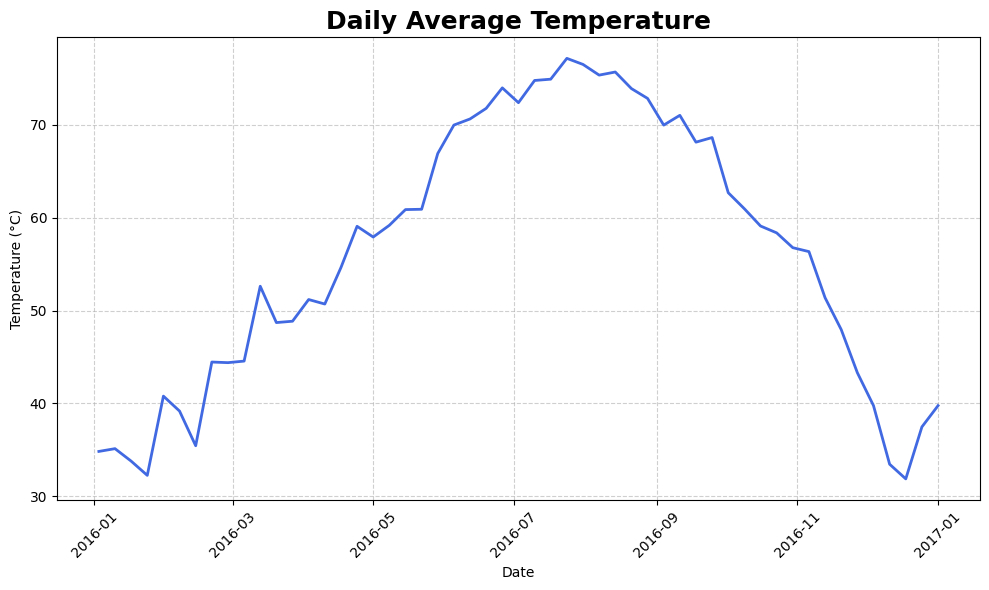

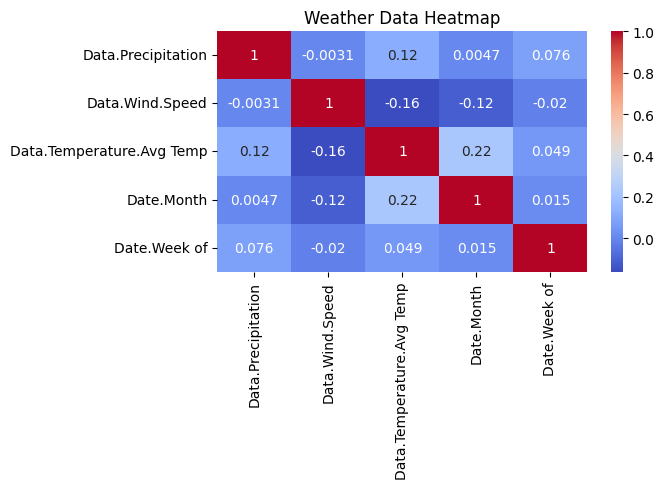

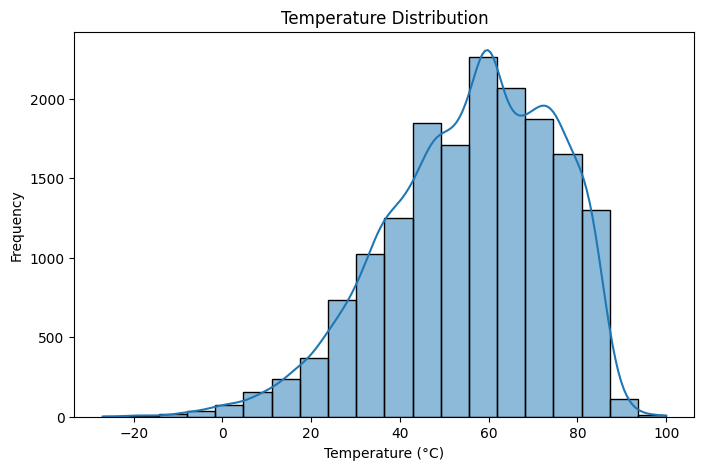

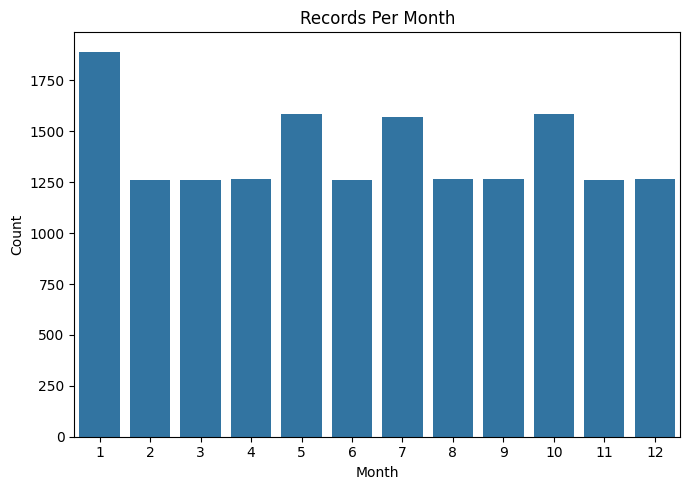

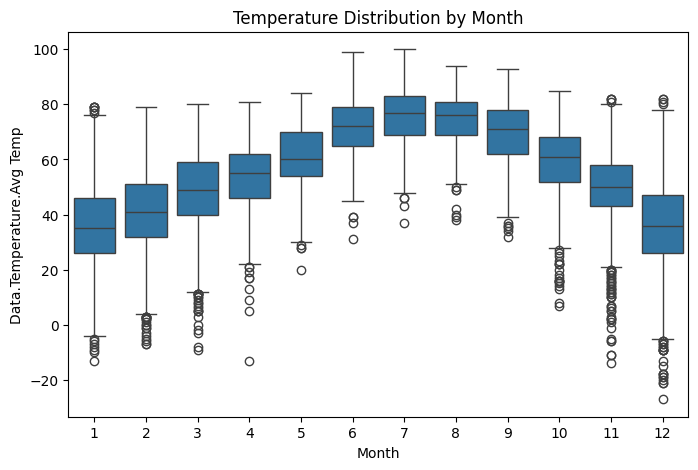

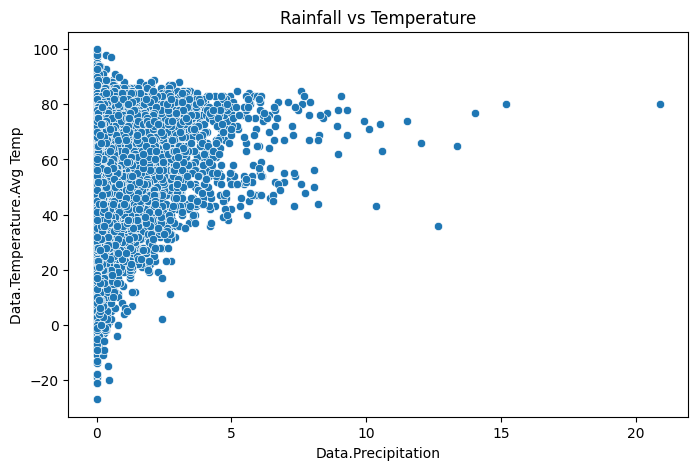

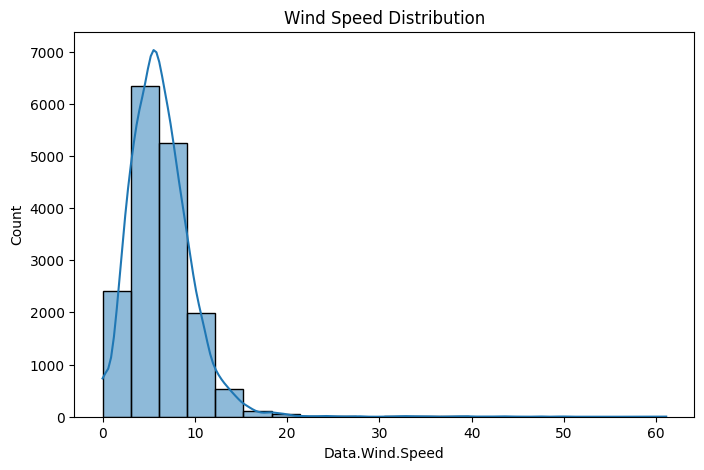

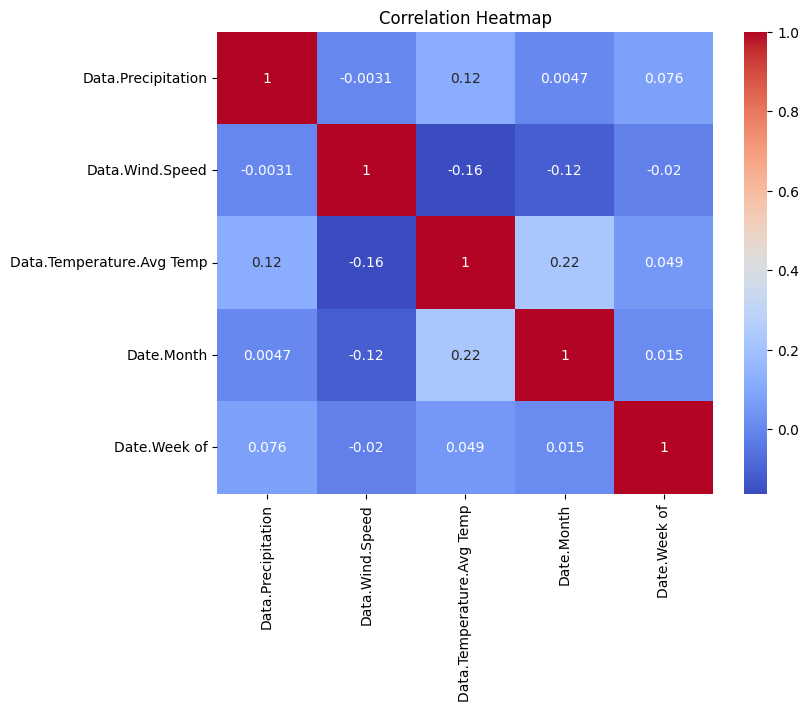

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r"C:\Users\anshs\OneDrive\Desktop\project\Weather Analysis\weather.csv"
df = pd.read_csv(file_path)

# Convert Date column
df["Date.Full"] = pd.to_datetime(df["Date.Full"])

print("***\nOriginal Data : ***")
print(df.head())
print(df.info())
print(df.describe())

# Fill Missing Values
df.fillna({
    "Data.Precipitation": 0,
    "Data.Wind.Speed": df["Data.Wind.Speed"].mean()
}, inplace=True)

# Create Month and Day Columns
df["Month"] = df["Date.Full"].dt.month
df["Day"] = df["Date.Full"].dt.day

# Average Temperature
avg_temp = df["Data.Temperature.Avg Temp"].mean()
print(f"Average Temperature : {avg_temp:.2f} °C")

# Date Frequency
print(df["Date.Full"].value_counts().head())

# Daily Average Temperature
daily_avg = df.groupby("Date.Full")["Data.Temperature.Avg Temp"].mean()

plt.figure(figsize=(10,6))
plt.plot(
    daily_avg.index,
    daily_avg.values,
    color="royalblue",
    linewidth=2
)

plt.title("Daily Average Temperature", fontsize=18, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()



# Correlation Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(
    df[[
        "Data.Precipitation",
        "Data.Wind.Speed",
        "Data.Temperature.Avg Temp",
        "Date.Month",
        "Date.Week of"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Weather Data Heatmap")
plt.tight_layout()
plt.show()

# Temperature Distribution
plt.figure(figsize=(8,5))
sns.histplot(
    df["Data.Temperature.Avg Temp"],
    bins=20,
    kde=True
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

# Records Per Month (Correct Countplot)
plt.figure(figsize=(7,5))
sns.countplot(x="Month", data=df)

plt.title("Records Per Month")
plt.xlabel("Month")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Temperature Distribution by Month
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Month",
    y="Data.Temperature.Avg Temp",
    data=df
)

plt.title("Temperature Distribution by Month")
plt.show()

# Rainfall vs Temperature
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Data.Precipitation",
    y="Data.Temperature.Avg Temp",
    data=df
)

plt.title("Rainfall vs Temperature")
plt.show()

# Wind Speed Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["Data.Wind.Speed"],
    bins=20,
    kde=True
)

plt.title("Wind Speed Distribution")
plt.show()

# Correlation Heatmap
cols = [
    "Data.Precipitation",
    "Data.Wind.Speed",
    "Data.Temperature.Avg Temp",
    "Date.Month",
    "Date.Week of"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()